# Utilization Prediction

## a) Business Case

During the descriptives task, we defined three KPIs:

1) Utilization rate
2) Energy delivered per hour
3) Rate of registered user sessions

The business case behind these KPIs is defined as:

<br><br>
<center>
  <b style="font-size: 1.3em;">
    The prediction model enables the site operator to offer dynamic pricing to registered users to maximize revenue and energy throughput while smoothing demand.
  </b>
</center>
<br><br>

The model predicts the hourly utilization of a given site. This information can be used to offer dynamic pricing models: when utilization and energy delivered are low, prices can be lowered to encourage usage. Notifications can be sent to registered users, e.g. through an app, to increase engagement, improve site utilization and maximize energy throughput.


## b) Prediction Model

## Load Dataframes and inspect data

In [129]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns
import holidays
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import os
os.environ["KERAS_BACKEND"] = "torch"
from keras import Sequential, Input # sequential model: https://keras.io/guides/sequential_model/
from keras.layers import Dense


# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "session_data_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)


print("DataFrame loaded successfully:")
print(f"  merged_df shape: {merged_df.shape}")


DataFrame loaded successfully:
  merged_df shape: (65006, 27)


We choose site 2 for this task, as it is the public site and offers a higher potential for aquiring new customers.

In [130]:
print(merged_df.siteID.unique())
print(merged_df.stationID.dtype)
df_site_2 = merged_df[merged_df['siteID'] == '2']
df_site_2 = df_site_2.sort_values(by='connectionTime', ascending=True)

['1' '2']
object


In [131]:
mask = merged_df['charging_duration'] == merged_df['session_duration']
number = merged_df[mask].shape[0]
print(f"Number of sessions where charging duration equals session duration: {number}")

Number of sessions where charging duration equals session duration: 8479


In [4]:
print(df_site_2['stationID'].nunique())

55


## Data Processing: Create hourly data of sessions

We calculate the utilization per hour for each day

In [5]:
# function to create hourly features for site 2
def make_site2_hourly_features(df,
                               conn_col='connectionTime',
                               disc_col='disconnectTime',
                               station_col='stationID'):
    df = df.copy()
    df[conn_col] = pd.to_datetime(df[conn_col], errors='coerce')
    df[disc_col] = pd.to_datetime(df[disc_col], errors='coerce')

    n_stations = df[station_col].nunique()

    # function to calculate hourly contributions for each charging session
    def row_hour_contrib(row):
        start = row[conn_col]
        end = row[disc_col]
        if pd.isna(start) or pd.isna(end) or end <= start: # skip invalid rows
            return []

        bins = pd.date_range(  # one bin is a hour occupied by the session
            start=start.floor('h'),
            end=(end - pd.Timedelta(seconds=1)).floor('h'),
            freq='h'
        )

        out = []
        for b in bins: # calculate contribution of sesson to each hour bin
            h_start = max(start, b)
            h_end = min(end, b + pd.Timedelta(hours=1))
            hours = (h_end - h_start).total_seconds() / 3600.0
            if hours > 0:
                # append hourly contribution
                out.append({
                    'datetime': b,
                    'hours': hours
                })
        return out

    contrib = df.apply(row_hour_contrib, axis=1)
    tmp = pd.DataFrame([item for lst in contrib for item in lst])

    if tmp.empty:
        return pd.DataFrame(columns=[
            'datetime', 'hourly_utilization_hours', 'hourly_utilization'
        ])

    # Hourly aggregation for session contributions within each hour
    hourly = (
        tmp.groupby('datetime', as_index=False)
            .agg(
                hourly_utilization_hours=('hours', 'sum'),
            )
    )
    # calculate hourly utilization as a fraction of total available hours
    hourly['hourly_utilization'] = (
        hourly['hourly_utilization_hours'] / (n_stations * 1.0)
    ).clip(0, 1)
    return hourly

    

In [6]:
df_site_2_features = make_site2_hourly_features(df_site_2, 'connectionTime', 'disconnectTime')
df_site_2_features.drop(columns=['hourly_utilization_hours'], inplace=True)
df_site_2_features.head()

,datetime,hourly_utilization
0,2018-04-25 04:00:00-07:00,0.015737
1,2018-04-25 05:00:00-07:00,0.018182
2,2018-04-25 06:00:00-07:00,0.014899
3,2018-04-25 07:00:00-07:00,0.058298
4,2018-04-25 08:00:00-07:00,0.248985


In [7]:
print((df_site_2_features['hourly_utilization'] < 0).any())

False


In [8]:
df_site_2_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20703 entries, 0 to 20702
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   datetime            20703 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization  20703 non-null  float64                            
dtypes: datetime64[ns, America/Los_Angeles](1), float64(1)
memory usage: 323.6 KB


## Feature Engineering

### Add "during_covid" boolean

We identified a structural break in the data probably caused by the corona pandemic.

DatetimeIndex(['2018-04-25 04:00:00-07:00', '2018-04-25 05:00:00-07:00',
               '2018-04-25 06:00:00-07:00', '2018-04-25 07:00:00-07:00',
               '2018-04-25 08:00:00-07:00', '2018-04-25 09:00:00-07:00',
               '2018-04-25 10:00:00-07:00', '2018-04-25 11:00:00-07:00',
               '2018-04-25 12:00:00-07:00', '2018-04-25 13:00:00-07:00',
               ...
               '2021-09-13 11:00:00-07:00', '2021-09-13 12:00:00-07:00',
               '2021-09-13 13:00:00-07:00', '2021-09-13 14:00:00-07:00',
               '2021-09-13 15:00:00-07:00', '2021-09-13 16:00:00-07:00',
               '2021-09-13 17:00:00-07:00', '2021-09-13 18:00:00-07:00',
               '2021-09-13 19:00:00-07:00', '2021-09-13 20:00:00-07:00'],
              dtype='datetime64[ns, America/Los_Angeles]', length=29705, freq='h')


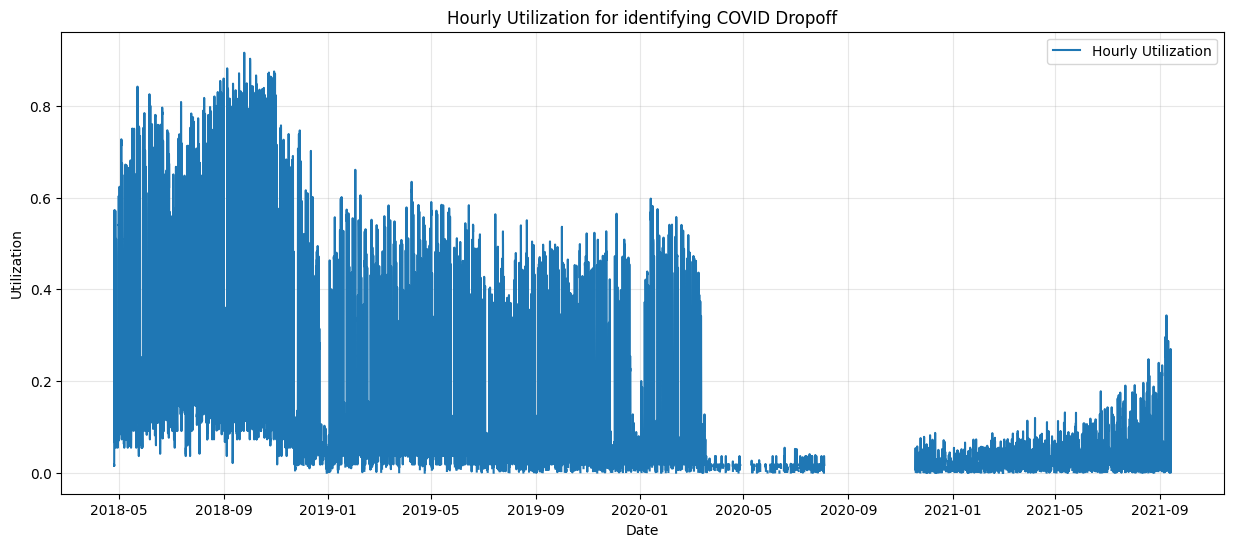

In [9]:
# Create a continuous hourly range from the very start to the very end
full_range = pd.date_range(start=df_site_2_features['datetime'].min(), 
                           end=df_site_2_features['datetime'].max(), 
                           freq='h')
print(full_range)
# Set datetime as index and reindex to show where the gaps are (will fill missing hours with NaN)
df_reindexed = df_site_2_features.set_index('datetime').reindex(full_range)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(df_reindexed.index, df_reindexed['hourly_utilization'], label='Hourly Utilization', color='tab:blue')



plt.title('Hourly Utilization for identifying COVID Dropoff')
plt.xlabel('Date')
plt.ylabel('Utilization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

It becomes clear that the dropoff is around early 2020. To identify the exact cutoff value we use the rolling averages with a 7-day rolling mean. We look for the biggest negative change in weekly utilization.

Detected COVID utilization dropoff starting: 2020-03-29 00:00:00-07:00
Largest week-over-week utilization drop: -0.1352

Value counts for 'during_covid':
during_covid
0    15494
1     5209
Name: count, dtype: int64


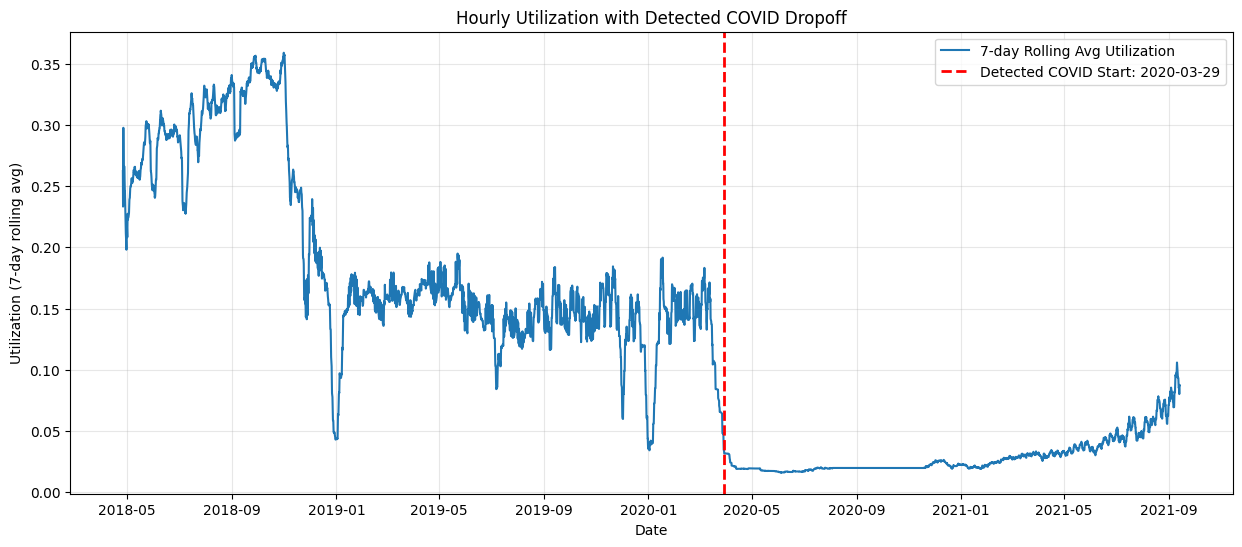

In [10]:
#1. Detect the COVID utilization dropoff (significant sustained drop in utilization)

df_temp = df_site_2_features.copy()
df_temp = df_temp.set_index('datetime').sort_index()

# Use a 7-day rolling mean to smooth the data
rolling_util = df_temp['hourly_utilization'].rolling(window=24*7, min_periods=24).mean()

# Focus on the period around COVID (2019-2020)
mask_2020 = (rolling_util.index >= '2019-06-01') & (rolling_util.index <= '2020-06-01')
rolling_2020 = rolling_util[mask_2020]

# Calculate the week-over-week change in utilization
util_change = rolling_2020.diff(periods=24*7)  # Compare to 1 week ago

# Find the point with the largest drop (most negative change)
covid_start_idx = util_change.idxmin()
covid_cutoff = pd.Timestamp(covid_start_idx).floor('D')  # Round to day

print(f"Detected COVID utilization dropoff starting: {covid_cutoff}")
print(f"Largest week-over-week utilization drop: {util_change.min():.4f}")

#2 Add 'during_covid' column based on detected dropoff (1 if date is after dropoff else 0)
df_site_2_features['during_covid'] = (df_site_2_features['datetime'] >= covid_cutoff).astype(int)

# Verify the split
print("\nValue counts for 'during_covid':")
print(df_site_2_features['during_covid'].value_counts())

# 3. Visualize to confirm detection
plt.figure(figsize=(15, 6))
plt.plot(rolling_util.index, rolling_util.values, label='7-day Rolling Avg Utilization', color='tab:blue')
plt.axvline(covid_cutoff, color='red', linestyle='--', linewidth=2, label=f'Detected COVID Start: {covid_cutoff.date()}')
plt.title('Hourly Utilization with Detected COVID Dropoff')
plt.xlabel('Date')
plt.ylabel('Utilization (7-day rolling avg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The dates are consistent with the outbreak of corona in 2020. So we use the binary encoded feature **during_covid** to quantify the effect.

### Add holiday, month, day of week, hour of day features

Public holidays are typically associated with a sharp drop in workplace attendance, especially at office-centric sites where charging demand is driven by commuters and employees. As a result, the number of vehicles arriving and plugging in decreases significantly, which leads to noticeably lower charging-station utilization during those days compared with regular working days.

Because this “holiday effect” is structural (it recurs every year and can be much stronger than normal day-to-day variation), it should be modeled explicitly rather than treated as random noise. In practical terms, adding a binary `isholiday` feature helps the model distinguish between two different operating regimes—standard workdays with predictable commuting peaks versus holidays with suppressed demand—reducing the risk of systematically overestimating utilization on those dates. In the notebook, this rationale is used directly to motivate the creation of holiday-related features (e.g., `isholiday`) alongside other calendar variables such as month, day of week, and hour.

In [11]:
US_holidays = holidays.US(state='CA')

# Ensure index is datetime
df_site_2_features['datetime'] = pd.to_datetime(df_site_2_features['datetime'])

df_site_2_features['is_holiday'] = df_site_2_features['datetime'].apply(lambda dt: dt in US_holidays)
df_site_2_features['is_holiday'] = df_site_2_features['is_holiday'].astype(int)

#Add time features based on the index
df_site_2_features['year'] = df_site_2_features['datetime'].dt.year
df_site_2_features['month'] = df_site_2_features['datetime'].dt.month
df_site_2_features['day'] = df_site_2_features['datetime'].dt.day
df_site_2_features['hour'] = df_site_2_features['datetime'].dt.hour
df_site_2_features['dayofweek'] = df_site_2_features['datetime'].dt.dayofweek
df_site_2_features['is_weekend'] = df_site_2_features['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

def get_season(month):
    if month in [12, 1, 2]:
        return 0
    elif month in [3, 4, 5]:
        return 1
    elif month in [6, 7, 8]:
        return 2
    else:
        return 3
    


    
df_site_2_features['season'] = df_site_2_features['month'].apply(get_season)

In [12]:
df_site_2_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20703 entries, 0 to 20702
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   datetime            20703 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization  20703 non-null  float64                            
 2   during_covid        20703 non-null  int64                              
 3   is_holiday          20703 non-null  int64                              
 4   year                20703 non-null  int32                              
 5   month               20703 non-null  int32                              
 6   day                 20703 non-null  int32                              
 7   hour                20703 non-null  int32                              
 8   dayofweek           20703 non-null  int32                              
 9   is_weekend          20703 non-null  int

### Create cyclic Features

We create cyclic features from time-related columns (hour, day of week, month, year) so the model learns their periodic nature instead of treating them as ordinary integers.

**Why cyclic encoding?**

Many calendar variables “wrap around”: 23:00 is close to 00:00, Sunday is close to Monday, and December is close to January. If we keep these as integers, a regression model may interpret the step from 23 → 0 (or 12 → 1) as a large discontinuity, even though the points are neighbors in time. Cyclic encoding fixes this by mapping each value onto a point on the unit circle using sine and cosine, making nearby times have nearby representations.

**How it works (sin & cos pair)**

For a cyclic variable x with period P, we compute:


$$ x_{\sin}=\sin\left(2\pi\frac{x}{P}\right)$$
$$x_{\cos}=\cos\left(2\pi\frac{x}{P}\right)$$



Using both sine and cosine is important: sine alone cannot uniquely represent positions around a circle, while the pair (sin⁡,cos⁡)(sin,cos) preserves the full circular position.


In [13]:
def create_cyclic_features(df):
    df = df.copy()

    # Hour of day
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Day of week
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    # Month of year
    df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)

    # Year
    df['year_sin'] = np.sin(2 * np.pi * (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min() + 1))
    df['year_cos'] = np.cos(2 * np.pi * (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min() + 1))
    
    
    return df


In [14]:
df_site_2_features = create_cyclic_features(df_site_2_features)
df_site_2_features.head()

,datetime,hourly_utilization,during_covid,is_holiday,year,month,day,hour,dayofweek,is_weekend,season,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos,year_sin,year_cos
0,2018-04-25 04:00:00-07:00,0.015737,0,0,2018,4,25,4,2,0,1,0.866025,5.000000e-01,0.974928,-0.222521,1.0,6.123234e-17,0.0,1.0
1,2018-04-25 05:00:00-07:00,0.018182,0,0,2018,4,25,5,2,0,1,0.965926,2.588190e-01,0.974928,-0.222521,1.0,6.123234e-17,0.0,1.0
2,2018-04-25 06:00:00-07:00,0.014899,0,0,2018,4,25,6,2,0,1,1.000000,6.123234e-17,0.974928,-0.222521,1.0,6.123234e-17,0.0,1.0
3,2018-04-25 07:00:00-07:00,0.058298,0,0,2018,4,25,7,2,0,1,0.965926,-2.588190e-01,0.974928,-0.222521,1.0,6.123234e-17,0.0,1.0
4,2018-04-25 08:00:00-07:00,0.248985,0,0,2018,4,25,8,2,0,1,0.866025,-5.000000e-01,0.974928,-0.222521,1.0,6.123234e-17,0.0,1.0


In [15]:
df_site_2_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20703 entries, 0 to 20702
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   datetime            20703 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization  20703 non-null  float64                            
 2   during_covid        20703 non-null  int64                              
 3   is_holiday          20703 non-null  int64                              
 4   year                20703 non-null  int32                              
 5   month               20703 non-null  int32                              
 6   day                 20703 non-null  int32                              
 7   hour                20703 non-null  int32                              
 8   dayofweek           20703 non-null  int32                              
 9   is_weekend          20703 non-null  int

## Feature Selection

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_site_2_features.copy()
df_plot['day_name'] = df_plot['datetime'].dt.day_name()
df_plot['hour'] = df_plot['datetime'].dt.hour
df_plot['month_name'] = df_plot['datetime'].dt.month_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

### Average Utilization by day of Week

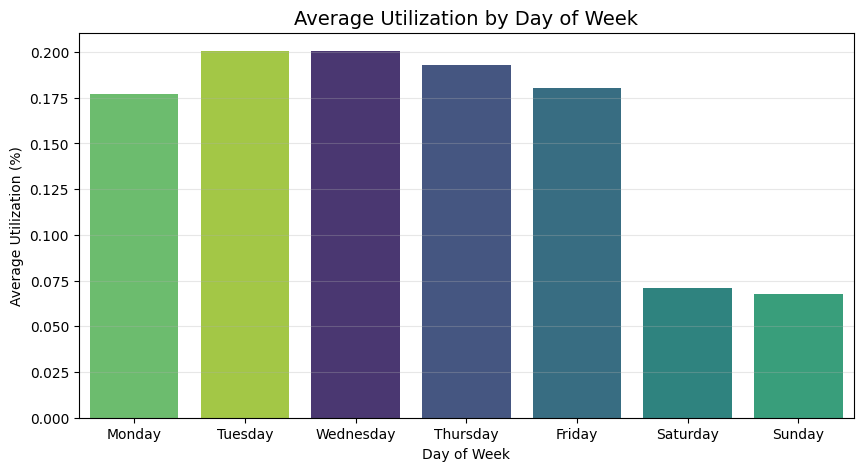

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_plot, 
    x='day_name', 
    y='hourly_utilization', 
    order=day_order, 
    palette='viridis', 
    hue='day_name',
    legend=False,
    errorbar=None
)
plt.title('Average Utilization by Day of Week', fontsize=14)
plt.ylabel('Average Utilization (%)')
plt.xlabel('Day of Week')
plt.grid(axis='y', alpha=0.3)
plt.show()

The data shows big contrast between high week utilization and near zero weekend usage. Therefore, we asssume day of the week to be a useful predictor of utilization.

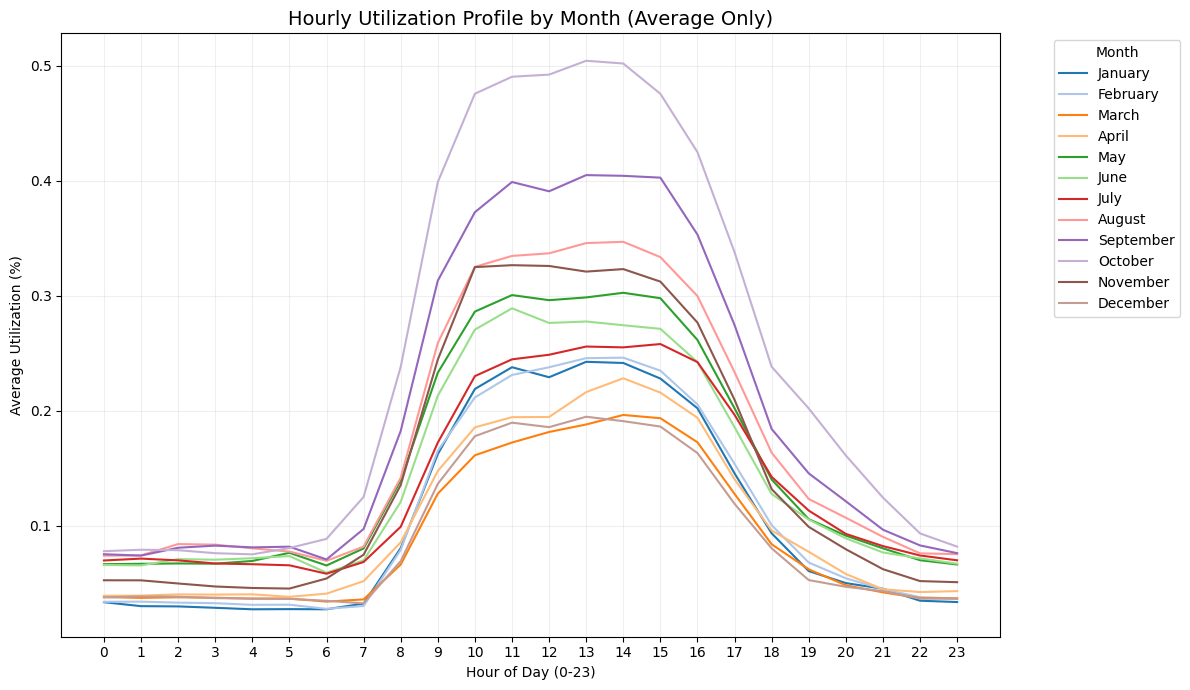

In [18]:
plt.figure(figsize=(12, 7))

sns.lineplot(data=df_plot, x='hour', y='hourly_utilization', 
             hue='month_name', hue_order=month_order, 
             palette='tab20', errorbar=None)

plt.title('Hourly Utilization Profile by Month (Average Only)', fontsize=14)
plt.ylabel('Average Utilization (%)')
plt.xlabel('Hour of Day (0-23)')
plt.xticks(range(0, 24))
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

As shown in the Figure above, the average utilization varies significantly at different times of the day. This temporal variation highlights the importance of including a hour of the day feature in the model, enabling the model to learn patterns based on the time of the day. Similarly, the data displays seasonal fluctuations and across different months. This monthly variation necessitates the inclusion of a month feature to allow the model to capture recurring seasonal patterns.

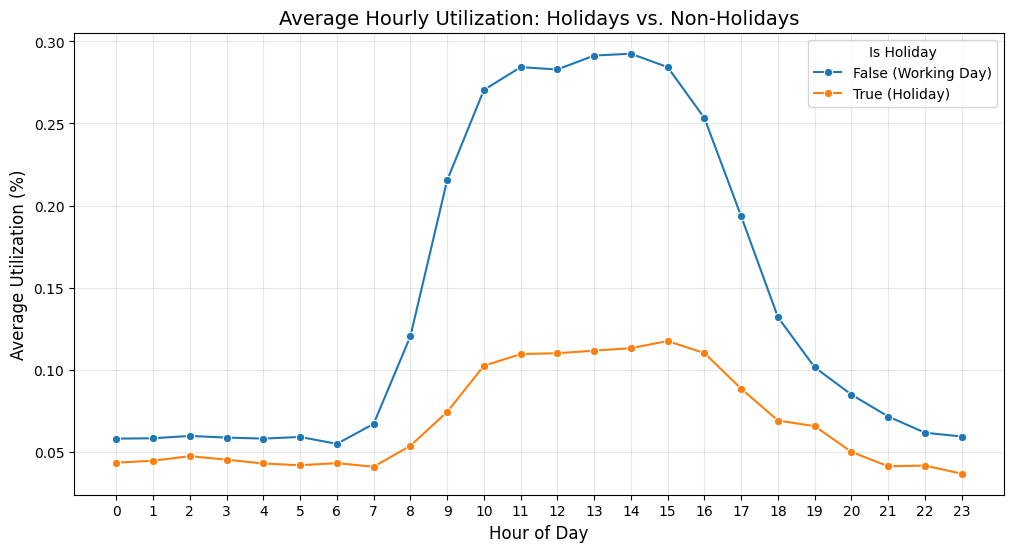

In [19]:
# Visualize average utilization: Holidays vs. Non-Holidays
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_site_2_features, 
    x='hour', 
    y='hourly_utilization', 
    hue='is_holiday', 
    marker='o',
    errorbar=None  # Shows the mean only;
)

plt.title('Average Hourly Utilization: Holidays vs. Non-Holidays', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Utilization (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

# Update legend for clarity
plt.legend(title='Is Holiday', labels=['False (Working Day)', 'True (Holiday)'])
plt.show()

As illustrated in the figure above, the average utilization on public holidays is much lower compared to working days.  This necessitates the inclusion of an is_holiday feature, allowing the model to differentiate between these two modes of behavior and avoid over estimating demand during public holidays.

In [20]:
df_site_2_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20703 entries, 0 to 20702
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   datetime            20703 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization  20703 non-null  float64                            
 2   during_covid        20703 non-null  int64                              
 3   is_holiday          20703 non-null  int64                              
 4   year                20703 non-null  int32                              
 5   month               20703 non-null  int32                              
 6   day                 20703 non-null  int32                              
 7   hour                20703 non-null  int32                              
 8   dayofweek           20703 non-null  int32                              
 9   is_weekend          20703 non-null  int

### Train Test Split

We split the dataset in **50% training data**, **20% validation data** and **30% test data**

In [21]:
x = df_site_2_features.drop(columns=['hourly_utilization', 'datetime', 'year_sin', 'year_cos', 'hour', 'dayofweek', 'month', 'year'])
y = df_site_2_features['hourly_utilization']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
x_train, x_hold, y_train, y_hold = train_test_split(x_train, y_train, test_size=(0.2/0.7), random_state=42)

print(len(x_train), len(x_hold), len(x_test))

10351 4141 6211


### Lasso Feature Selection

**Lasso** is a regularized linear regression technique that adds an L1 penalty term to the loss function. This penalty shrinks some coefficients to exactly zero, effectively performing automatic feature selection.

**Why Lasso for Feature Selection?**
- **Sparsity**: Unlike Ridge regression (L2), Lasso produces sparse models by eliminating irrelevant features entirely
- **Interpretability**: Features with non-zero coefficients are directly interpretable as important predictors

**Our Approach:**
1. **StandardScaler**: Normalize features so regularization penalizes all coefficients equally
2. **LassoCV**: Cross-validation automatically selects the optimal regularization strength (α)
3. **Threshold (|coef| > 0.01)**: Features with coefficients below this threshold are considered noise and excluded

This step reduces model complexity and improves generalization for downstream models like polynomial regression.

In [22]:
# feature selection with Lasso to rank cyclic and lag features
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

lasso_features = x

lasso_selector = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=42))
lasso_selector.fit(x_train[lasso_features.columns], y_train)

lasso_coefs = lasso_selector.named_steps['lassocv'].coef_
threshold = 0.0
selected_features = [feat for feat, coef in zip(lasso_features.columns, lasso_coefs) if abs(coef) > threshold]

feature_importance = pd.DataFrame({
    'feature': lasso_features.columns,
    'coef': lasso_coefs,
    'abs_coef': np.abs(lasso_coefs)
}).sort_values('abs_coef', ascending=False)

if selected_features:
    x_train = x_train[selected_features]
    x_hold = x_hold[selected_features]
    x_test = x_test[selected_features]
else:
    x_train = x_train.copy()
    x_hold = x_hold.copy()
    x_test = x_test.copy()

print("Selected features (|coef| > 0.0):", selected_features)
feature_importance

Selected features (|coef| > 0.0): ['during_covid', 'is_holiday', 'day', 'is_weekend', 'season', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'month_sin', 'month_cos']


,feature,coef,abs_coef
6,hour_cos,-0.098369,0.098369
0,during_covid,-0.085230,0.085230
3,is_weekend,-0.045054,0.045054
5,hour_sin,-0.034894,0.034894
10,month_cos,-0.020442,0.020442
4,season,0.016173,0.016173
1,is_holiday,-0.013749,0.013749
7,dayofweek_sin,0.007842,0.007842
9,month_sin,-0.003521,0.003521
2,day,-0.001055,0.001055


C:\Users\nilsb\AppData\Local\Temp\ipykernel_27080\2512387465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='abs_coef', y='feature', palette='viridis')


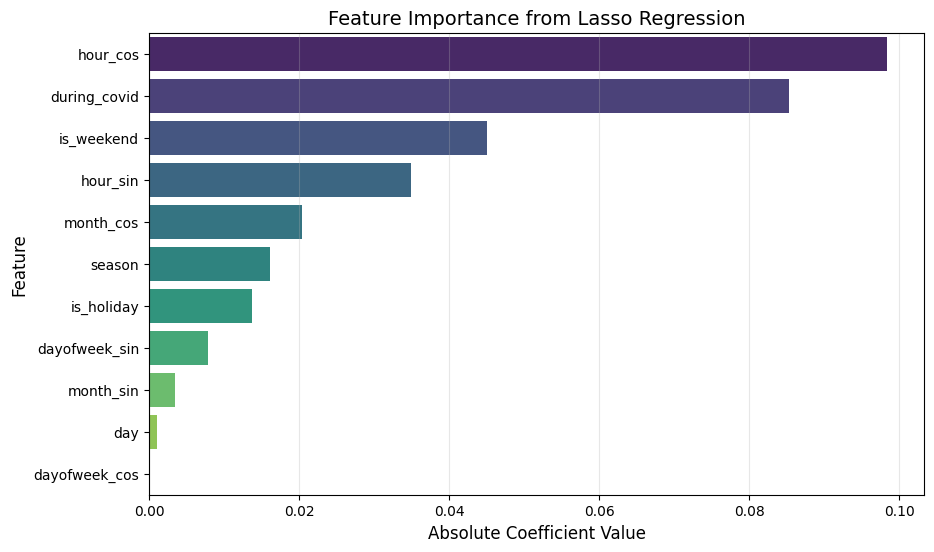

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='abs_coef', y='feature', palette='viridis')
plt.title('Feature Importance from Lasso Regression', fontsize=14)
plt.xlabel('Absolute Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

**Results Interpretation:**

The Lasso regression reveals a clear hierarchy of feature importance for predicting charging hub utilization:

| Feature | abs(Coefficient) | Interpretation |
|---------|-------------|----------------|
| `hour_cos` & `hour_sin` | 0.0967 & 0.0336 | **Strongest predictor** – captures the daily utilization cycle (peak during work hours) |
| `during_covid` | 0.0852 | Pre-pandemic periods had higher utilization than post-COVID |
| `is_weekend` | 0.0459 | Weekends show significantly lower utilization (negative coefficient) |
| `month_cos` & `month_sin` | 0.0212 & 0.0041 | Seasonal variation in charging behavior |
| `is_holiday` | 0.0139 | Holidays reduce utilization (workplace charging hub) |
| `dayofweek_sin` & `dayofweek_cos` | 0.0065 & 0.0003 | Mid-week days (Tue-Thu) show different patterns than Mon/Fri |





**Excluded Features (coef != 0.0):**
- `day`: Day of month has no meaingful predictive power (|coef| > 0.0)

Using a threshold of |coef| > 0.009, we retain 9 features and exclude `day` and `season` to reduce noise and improve model generalization.

In [ ]:
print("Final features used for modeling:", x_train.columns.tolist())
x_train.info()

Final features used for modeling: ['during_covid', 'is_holiday', 'day', 'is_weekend', 'season', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'month_sin', 'month_cos']
<class 'pandas.core.frame.DataFrame'>
Index: 10351 entries, 13775 to 17389
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   during_covid   10351 non-null  int64  
 1   is_holiday     10351 non-null  int64  
 2   day            10351 non-null  int32  
 3   is_weekend     10351 non-null  int64  
 4   season         10351 non-null  int64  
 5   hour_sin       10351 non-null  float64
 6   hour_cos       10351 non-null  float64
 7   dayofweek_sin  10351 non-null  float64
 8   month_sin      10351 non-null  float64
 9   month_cos      10351 non-null  float64
dtypes: float64(5), int32(1), int64(4)
memory usage: 849.1 KB


## Training Test Validation Split on selected features

## Modeling

### Regression Code

We run different models of polynomial regression with ridge and lasso regularization to predict hourly utilization. Our approach includes:

1. **Polynomial Features**: We test polynomial degrees from 1 to 7 to capture non-linear relationships the features from the session data set

2. **Model Types**:
   - **Linear Regression**: Baseline model without regularization
   - **Ridge Regression**: L2 regularization to penalize large coefficients and reduce overfitting
   - **Lasso Regression**: L1 regularization to perform feature selection while reducing overfitting

3. **Regularization Strength**: For Ridge and Lasso, we test alpha values [0.01, 0.1, 1, 10] to find optimal regularization strength. Higher alpha values increase the penalty.

4. **Cross-validation Approach**: We train on the training set and evaluate on the holdout set using the R² metric to prevent overfitting and select the best model.

5. **Using a pipeline**: We use a pipeline to ensure consistent and correct preprocessing for prediction

The goal is to find the model that best generalizes to unseen data by balancing model complexity with prediction accuracy, as measured by the R² score which indicates the proportion of variance explained by the model.

In [153]:
degrees = range(1, 8)
alphas = [0.01, 0.1, 1, 10]
models = ["linear", "Ridge", "Lasso"]
results = []

In [154]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

def build_model(model, degree, alpha=None):
    if model == 'Ridge':
        reg = Ridge(alpha=alpha)
    elif model == 'Lasso':
        reg = Lasso(alpha=alpha, max_iter=10000)
    else:
        reg = LinearRegression()

    pipeline = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        reg
    )
    return pipeline


In [155]:
def run_models(models, degrees, alphas, 
               x_train, x_hold, y_train, y_hold):
    rows = []  # list of dicts, reusable each call

    for model in models:
        for degree in degrees:
            
            if model in ["Ridge", "Lasso"]:
                for alpha in alphas:
                    pipeline = build_model(model, degree, alpha)
                    pipeline.fit(x_train, y_train)
                    y_hold_pred = pipeline.predict(x_hold)
                    mse_val = mean_squared_error(y_hold, y_hold_pred)
                    r2_val = r2_score(y_hold, y_hold_pred)

                    rows.append({
                        "model": model,
                        "degree": degree,
                        "alpha": alpha,
                        "mse": mse_val,
                        "r2": r2_val,
                        "pipeline": pipeline
                    })
            else:
                pipeline = build_model("LinearRegression", degree)
                pipeline.fit(x_train, y_train)
                y_hold_pred = pipeline.predict(x_hold)
                mse_val = mean_squared_error(y_hold, y_hold_pred)

                rows.append({
                    "model": model,
                    "degree": degree,
                    "alpha": None,
                    "mse": mse_val,
                    "r2": r2_score(y_hold, y_hold_pred),
                    "pipeline": pipeline
                })

    return pd.DataFrame(rows)


In [28]:
# get the model with the highest R2 on holdout set
results = run_models(models, degrees, alphas, x_train, x_hold, y_train, y_hold)
best_idx = results["r2"].idxmax()
best_regression_model = results.loc[best_idx, 'pipeline']
print(results.loc[best_idx, ['model', 'degree', 'alpha', 'r2', 'mse']])

model        Ridge
degree           5
alpha         10.0
r2        0.812408
mse       0.006714
Name: 26, dtype: object


We see that the best model uses **Ridge regularization**, has a **polynomial degree of 5** with an alpha of **10.0**. This configuration indicates that:

- **Ridge Regression** was more effective than Lasso, suggesting that all features contribute meaningfully to predicting charging duration rather than needing feature selection.
- **Polynomial degree 5** captures complex non-linear relationships between the features of the session dataset, suggesting that the interaction between multiple session factors is important.
- **High alpha (10.0)** means high regularization penalty was needed, indicating the model does suffer from severe overfitting with the polynomial features.

The model's performance on the holdout set yields an **R² score of 0.81**, meaning it explains 81% of the variance in utilzation of the charging hubs. This is a solid result indicating good predictive power while leaving some variance unexplained, which could be attributed to factors not captured in the session data alone(e.g. weather, ...)

In [29]:
y_pred_reg = best_regression_model.predict(x_test)

# calculate test metrics
mse_test_reg = mean_squared_error(y_test, y_pred_reg)
rmse_test_reg = np.sqrt(mse_test_reg)  # Root Mean Squared Error
r2_test_reg = r2_score(y_test, y_pred_reg)
mae_test_reg = mean_absolute_error(y_test, y_pred_reg)

print(f"Test RMSE: {rmse_test_reg}")
print(f"Test R2: {r2_test_reg}")
print(f'Difference in R2 (Holdout vs Test): {(results.loc[best_idx, "r2"] - r2_test_reg) * 100:.2f}%')



Test RMSE: 0.08204989293750872
Test R2: 0.8135737698215468
Difference in R2 (Holdout vs Test): -0.12%


On the test set, we achieve an **R² score of 0.8022**, which is slightly lower than the holdout set performance (0.8135). This modest increase of around 0,12% is expected and indicates good generalization, meaning the model doesn't show signs of significant overfitting. The test R² of 0.8022 means the model explains 80% of the variance in charging hub utilization on completely unseen data. The 0,5% difference between holdout and test performance suggests the model is stable and reliable for making predictions on new data.

In [158]:
# Create test metrics table for later comparison
test_metrics = pd.DataFrame(columns=["model_name", "r2", "rmse", "mae"])

# Create test metrics entry for Regression Model
test_metrics.loc[len(test_metrics)] = ["Regression Model", r2_test_reg, rmse_test_reg, mae_test_reg]

### Decision Tree Code

Decision trees offer a different approach to regression that captures complex non-linear relationships without requiring feature scaling or polynomial transformations. Unlike linear models, decision trees recursively partition the feature space based on feature values that minimize prediction error at each split, creating a hierarchical structure that is interpretable and can reveal feature interactions.

However, decision trees are prone to overfitting. Which leads to the problem that they memorize training data rather than learning generalizable patterns. To address this, we employ **GridSearchCV**, which systematically searches hyperparameters like `max_depth`, `min_samples_leaf` and `min_samples_split` to find the optimal tree complexity that balances bias and variance. This systematic hyperparameter tuning ensures we capture the tree's predictive power while preventing overfitting to training-specific noise.

In [31]:
df_tree = df_site_2_features.copy()
df_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20703 entries, 0 to 20702
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   datetime            20703 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization  20703 non-null  float64                            
 2   during_covid        20703 non-null  int64                              
 3   is_holiday          20703 non-null  int64                              
 4   year                20703 non-null  int32                              
 5   month               20703 non-null  int32                              
 6   day                 20703 non-null  int32                              
 7   hour                20703 non-null  int32                              
 8   dayofweek           20703 non-null  int32                              
 9   is_weekend          20703 non-null  int

In [160]:
cyclic_cols = ['hour_sin', 'hour_cos',
               'dayofweek_sin', 'dayofweek_cos',
               'month_sin', 'month_cos',
               'year_sin', 'year_cos']
df_tree = df_tree.drop(columns=cyclic_cols)

In [33]:
# Remove 'year' - it cannot extrapolate to future years and causes overfitting
x = df_tree.drop(columns=['hourly_utilization', 'datetime', 'year'])
y = df_tree['hourly_utilization']

x_train_tree, x_test_tree, y_train_tree, y_test_tree = train_test_split(x, y, test_size=0.3, random_state=42)
x_train_tree, x_hold_tree, y_train_tree, y_hold_tree = train_test_split(x_train_tree, y_train_tree, test_size=(0.2/0.7), random_state=42)

print(x_train_tree.columns.tolist())

['during_covid', 'is_holiday', 'month', 'day', 'hour', 'dayofweek', 'is_weekend', 'season']


In [162]:
# 1. Use these alphas in Grid Search
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree

param_grid = {
    'min_samples_leaf': [20, 50, 100],
    'min_samples_split': [50, 200, 500],
    'max_depth': [3, 5 ,7 ,9]
}

grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5)
grid_search.fit(x_train_tree, y_train_tree)

best_tree = grid_search.best_estimator_

**Model Selection Strategy**: Among all models from GridSearchCV, we select the tree with the **lowest tree depth** whose R² score falls within **10% of the best-performing tree** from the grid search. This approach prioritizes interpretability by favoring simpler trees while maintaining predictive performance close to the optimal model, ensuring we capture the tree's predictive power without overfitting to training-specific noise.

In [35]:
results = pd.DataFrame(grid_search.cv_results_)
top_models = results[results['mean_test_score'] >= results['mean_test_score'].max() * 0.90]

best_small_tree_idx = top_models['param_max_depth'].idxmin()

best_small_tree = grid_search.cv_results_['params'][best_small_tree_idx]
print("Best small tree params:", best_small_tree)


params = grid_search.cv_results_['params'][best_small_tree_idx]
print("Training best small tree with params:", params)
best_tree = DecisionTreeRegressor(
    min_samples_leaf=params['min_samples_leaf'],
    min_samples_split=params['min_samples_split'],
    max_depth=params['max_depth'],
    random_state=42
)
best_tree.fit(x_train_tree, y_train_tree)

Best small tree params: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 50}
Training best small tree with params: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 50}


,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,50
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


<Axes: title={'center': 'Feature Importance'}>

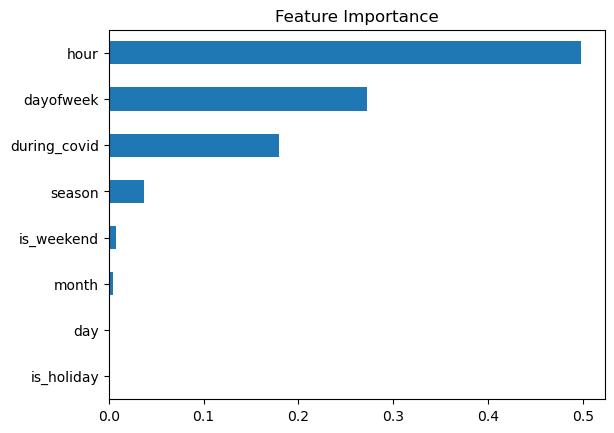

In [36]:
importances = pd.Series(best_tree.feature_importances_, index=x_train_tree.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance')

The feature importance plot reveals which variables the decision tree relied on most when making predictions.
**Hour** is the dominant predictor with an importance score of ~0.5, followed by **dayofweek** (~0.27),  **during_covid** (~0.17). **season, is_weekend, month, day & is_holiday** have a very low importance. These results indicate that temporal patterns—specifically the time of day and day of the week—are the strongest drivers of charging hub utilization, while seasonal and historical factors play supporting roles.

In [37]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Use the best estimator from your GridSearch to make predictions
y_pred_tree = best_tree.predict(x_test_tree)

# Calculate standard regression metrics
mse_tree = mean_squared_error(y_test_tree, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)  # Root Mean Squared Error
mae_tree = mean_absolute_error(y_test_tree, y_pred_tree)
r2_tree = r2_score(y_test_tree, y_pred_tree)

print("--- Model Performance on Test Set ---")
print(f"R-squared: {r2_tree:.4f}")
print(f"Mean Absolute Error (MAE): {mae_tree:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tree:.2f}")

--- Model Performance on Test Set ---
R-squared: 0.7301
Mean Absolute Error (MAE): 0.06
Root Mean Squared Error (RMSE): 0.10


In [166]:
# Add test metrics entry for Decision Tree
test_metrics.loc[len(test_metrics)] = ["Decision Tree", r2_tree, rmse_tree, mae_tree]


The decision tree model achieved strong performance on the test set with an **R² of 0.7301**, meaning it explains approximately 73% of the variance in charging hub utilization. The **MAE of 0.06** and **RMSE of 0.10** indicate low average prediction errors, demonstrating the model's effectiveness at capturing charging patterns and generalizing well to unseen data.

Best Hyperparameters: {'max_depth': 5, 'min_samples_split': 50, 'min_samples_leaf': 20}
Tree Depth: 5
Number of Leaves: 32


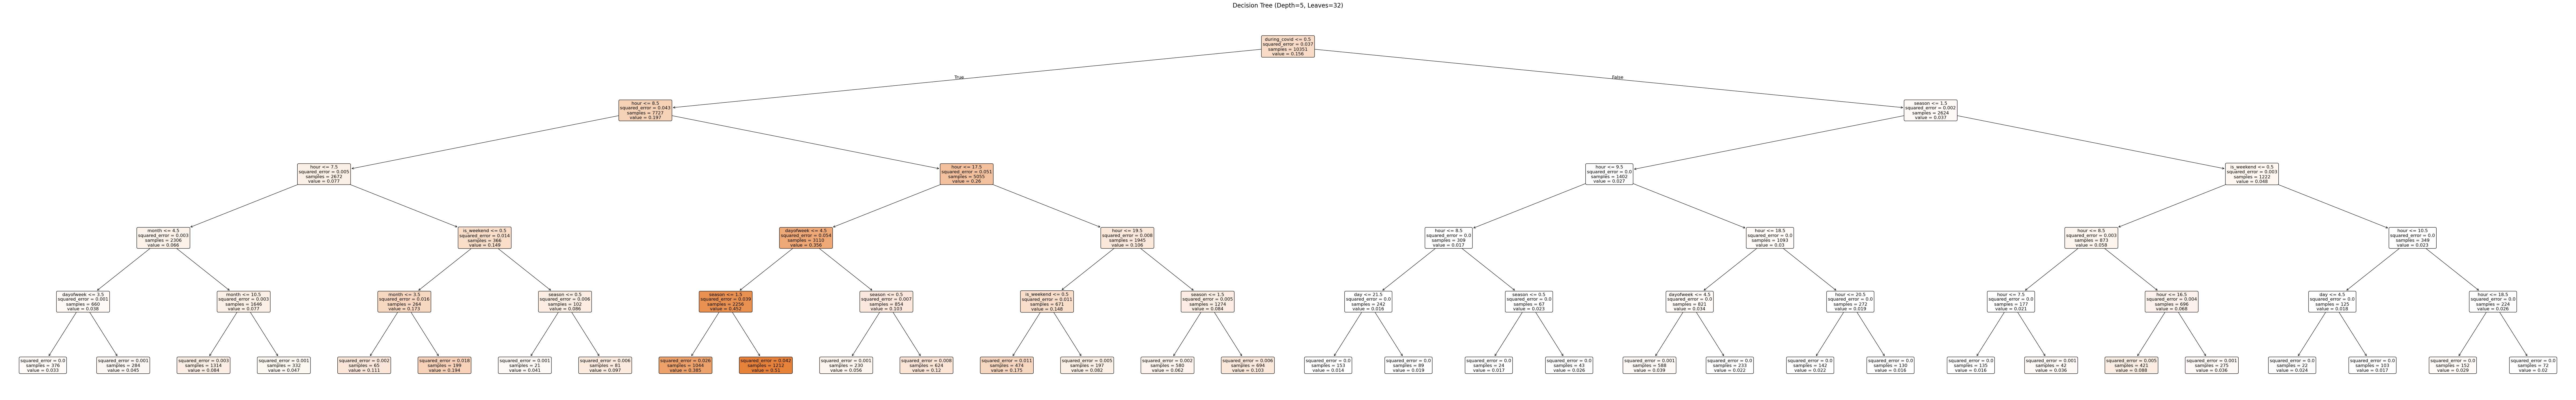

In [39]:
print("Best Hyperparameters:", {
    'max_depth': best_tree.get_params()['max_depth'],
    'min_samples_split': best_tree.get_params()['min_samples_split'],
    'min_samples_leaf': best_tree.get_params()['min_samples_leaf']
})
print(f"Tree Depth: {best_tree.get_depth()}")
print(f"Number of Leaves: {best_tree.get_n_leaves()}")

# Plot the actual tree - optimized for readability
n_leaves = best_tree.get_n_leaves()
tree_depth = best_tree.get_depth()

fig_width = max(20, n_leaves * 3)
fig_height = max(10, tree_depth * 3)

plt.figure(figsize=(fig_width, fig_height), dpi=100)
plot_tree(best_tree, 
          feature_names=x_train_tree.columns, 
          filled=True,
          rounded=True,
          fontsize=12,
          precision=3)
plt.title(f"Decision Tree (Depth={tree_depth}, Leaves={n_leaves})", fontsize=16, pad=20)
plt.tight_layout()
plt.show()


The tree visualization shows the decision rules, for when taking which branch of the tree.

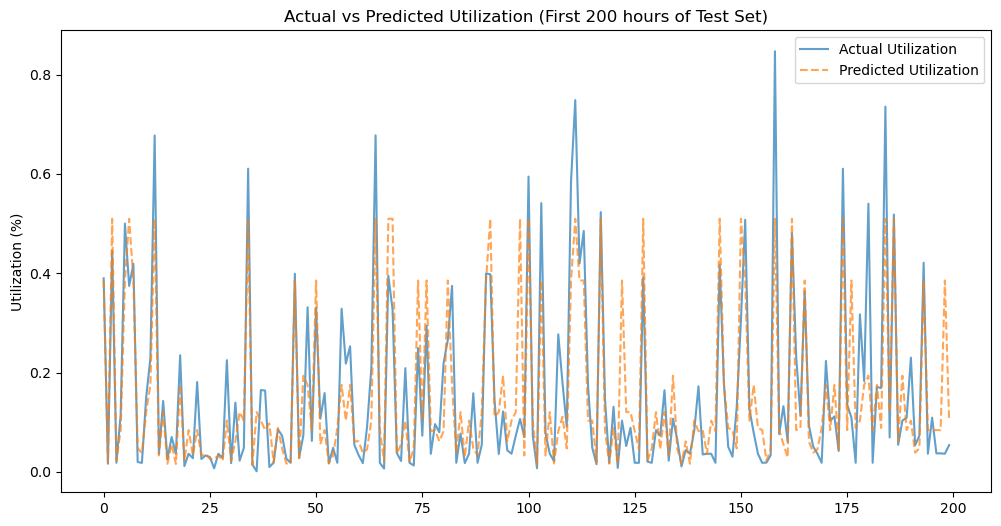

In [168]:
# 3. Quick visualization: Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_tree.values[:200], label='Actual Utilization', alpha=0.7)
plt.plot(y_pred_tree[:200], label='Predicted Utilization', alpha=0.7, linestyle='--')
plt.title('Actual vs Predicted Utilization (First 200 hours of Test Set)')
plt.ylabel('Utilization (%)')
plt.legend()
plt.show()

The actual vs predicted plot demonstrates strong alignment between the model's predictions (orange dashed line) and true charging utilization values (blue solid line). The model captures the sharp intra-day peaks and troughs characteristic of charging demand patterns, indicating it has learned the temporal structure well. While the predictions occasionally lag or smooth over extreme spikes, the overall trend tracking is excellent, confirming the decision tree's ability to generalize predictions to new, unseen data.

## NN

Neural networks offer a fundamentally different approach to regression compared to traditional tree-based methods. By stacking multiple layers of interconnected neurons with non-linear activation functions, neural networks can learn extremely complex patterns and interactions in data automatically. Unlike decision trees which use explicit rules, neural networks learn through iterative optimization—adjusting thousands of weights to minimize prediction error. This flexibility allows them to potentially capture subtle temporal dependencies and non-linear relationships in charging demand. However, this power comes with tradeoffs: neural networks require more data, careful hyperparameter tuning, longer training times, and are less interpretable than decision trees. We train a sequential neural network to compare its performance against the decision tree and evaluate whether the added complexity yields improved predictions.

In [169]:
# standardize features
st_scaler = StandardScaler()
st_scaler.fit(x_train)
x_train_scaled = st_scaler.transform(x_train)

In [42]:
# define neural network model
n_features = x_train_scaled.shape[1]
print(f"Number of input features: {n_features}")

nn_model = Sequential()

# Input layer - dynamically set based on feature count
nn_model.add(Input((n_features,)))

# Hidden layers
nn_model.add(Dense(64, activation='relu'))
nn_model.add(Dense(32, activation='relu'))

# Output layer
nn_model.add(Dense(1, activation=None))

nn_model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

Number of input features: 10


In [43]:
# print model summary
nn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

To address overfitting, we employ **early stopping**, which monitors the model's performance on a validation set during training and automatically halts training when the validation loss stops improving for 5 consecutive epochs (`patience=5`). The `restore_best_weights=True` parameter ensures the model automatically reverts to the weights from the epoch with the best validation performance.

**Early Stopping Strategy**: We configure early stopping to monitor `val_loss` with `patience=5` and use a 20% validation split from the training data (`validation_split=0.2`). Training is capped at 50 epochs as a safety net. This setup prevents overfitting while automatically capturing the network's optimal predictive capacity without manual epoch tuning, systematically balancing model complexity and generalization performance.

In [44]:
# define epochs and train the model with early stopping
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', # Monitor validation loss
                            patience=5, # Stop after 5 epochs of no improvement
                            restore_best_weights=True # Restore best weights after stopping
                            )

epochs = 50  # increased max epochs since early stopping will prevent overfitting
history = nn_model.fit(x_train_scaled, y_train,
                       epochs=epochs, 
                       validation_split=0.2,
                       callbacks=[early_stop],
                       verbose=1)

Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0181 - mae: 0.0963 - mse: 0.0181 - val_loss: 0.0102 - val_mae: 0.0749 - val_mse: 0.0102
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0094 - mae: 0.0711 - mse: 0.0094 - val_loss: 0.0091 - val_mae: 0.0706 - val_mse: 0.0091
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.0088 - mae: 0.0674 - mse: 0.0088 - val_loss: 0.0088 - val_mae: 0.0681 - val_mse: 0.0088
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0084 - mae: 0.0650 - mse: 0.0084 - val_loss: 0.0080 - val_mae: 0.0641 - val_mse: 0.0080
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0083 - mae: 0.0643 - mse: 0.0083 - val_loss: 0.0078 - val_mae: 0.0640 - val_mse: 0.0078
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0080 - mae: 0.0633 - mse: 0.0080 - val_loss: 0.0081 - val_mae: 0.0648 - val_mse: 0.0081
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0078 - mae: 0.0621 - mse: 0.00

In [45]:
# make predictions
nn_model.predict(x_train_scaled[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([[0.03149454],
       [0.09700431],
       [0.34343177],
       [0.07062918],
       [0.03592755],
       [0.2120169 ],
       [0.12917748],
       [0.08133304],
       [0.0399712 ],
       [0.10096686]], dtype=float32)

In [46]:
# convert training history to DataFrame for easier analysis
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,0.018117,0.096328,0.018117,0.010167,0.074901,0.010167
1,0.009441,0.071105,0.009441,0.009108,0.070582,0.009108
2,0.008754,0.067358,0.008754,0.008840,0.068073,0.008840
3,0.008399,0.065033,0.008399,0.007972,0.064057,0.007972
4,0.008252,0.064263,0.008252,0.007775,0.064016,0.007775
5,0.008035,0.063257,0.008035,0.008099,0.064788,0.008099
6,0.007810,0.062110,0.007810,0.007806,0.064007,0.007806
7,0.007768,0.061740,0.007768,0.008882,0.066508,0.008882
8,0.007517,0.060236,0.007517,0.007472,0.060899,0.007472
9,0.007549,0.060457,0.007549,0.008035,0.063135,0.008035


In [47]:
# calculate root mean squared error (RMSE) from MSE
root_metrics_df = history_df[['mse', 'val_mse']].apply(np.sqrt)
root_metrics_df.rename({'mse': 'rmse', 'val_mse': 'val_rmse'}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,0.134600,0.100833
1,0.097166,0.095435
2,0.093560,0.094022
3,0.091649,0.089283
4,0.090841,0.088176
5,0.089638,0.089993
6,0.088372,0.088350
7,0.088138,0.094242
8,0.086703,0.086441
9,0.086887,0.089636


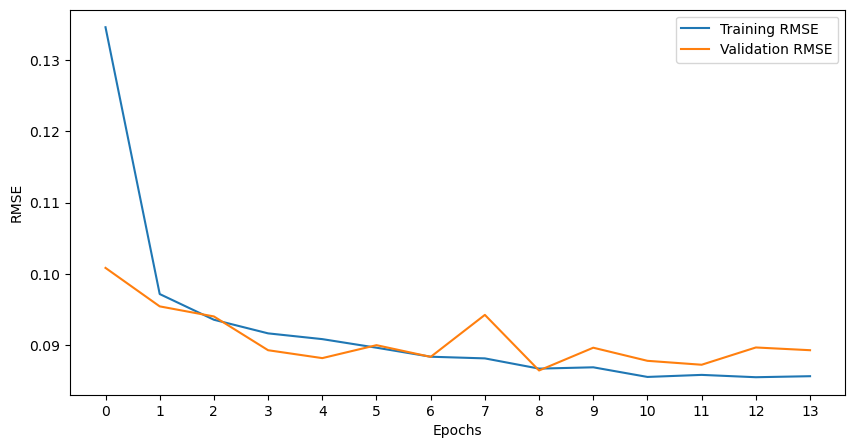

Training stopped at epoch 14


In [48]:
# plot training and validation RMSE over epochs
plt.figure(figsize=(10, 5))
plt.plot(root_metrics_df['rmse'], label='Training RMSE')
plt.plot(root_metrics_df['val_rmse'], label='Validation RMSE')

plt.xlabel('Epochs')
plt.ylabel('RMSE')

# Fix: use actual number of epochs from training history
plt.xticks(range(0, len(root_metrics_df), max(1, len(root_metrics_df)//10)))
plt.legend()

plt.show()

print(f"Training stopped at epoch {len(root_metrics_df)}")

The training RMSE curve shows rapid improvement in the first epoch, with the metrics dropping sharply **to ~0.095**. While the  validation RMSE curve shows rapid improvement in the first epoch. After epoch 1, **convergence stabilizes and both curves plateau around 0.09**.The **close alignment between training and validation RMSE throughout training indicates the model is not overfitting**. Meaning it generalizes well to unseen validation data. The slight bump around epochs 3-4 suggests minor noise in the optimization process, but overall the learning trajectory is healthy and indicates the model has successfully converged.

In [49]:
# Evaluate on holdout set first (consistent with other models)
x_hold_scaled = st_scaler.transform(x_hold)
y_pred_hold_nn = nn_model.predict(x_hold_scaled)

print("--- Neural Network Performance on Holdout Set ---")
print(f"R-squared: {r2_score(y_hold, y_pred_hold_nn):.4f}")
print(f"MAE: {mean_absolute_error(y_hold, y_pred_hold_nn):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_hold, y_pred_hold_nn)):.4f}")

 60/130 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
--- Neural Network Performance on Holdout Set ---
R-squared: 0.7866
MAE: 0.0609
RMSE: 0.0874


In [50]:
# Final evaluation on test set
x_test_scaled = st_scaler.transform(x_test)
y_pred_nn = nn_model.predict(x_test_scaled)

# Calculate standard regression metrics
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)  # Root Mean Squared Error
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("--- Neural Network Performance on Test Set ---")
print(f"R-squared: {r2_nn:.4f}")
print(f"Mean Absolute Error (MAE): {mae_nn:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_nn:.4f}")

111/195 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
--- Neural Network Performance on Test Set ---
R-squared: 0.7861
Mean Absolute Error (MAE): 0.0609
Root Mean Squared Error (RMSE): 0.0879


In [179]:
# Add test metrics entry for Neural Network
test_metrics.loc[len(test_metrics)] = ["Neural Network", r2_nn, rmse_nn, mae_nn]

### Summary

In [52]:
test_metrics.head()

,model_name,r2,rmse,mae
0,Regression Model,0.813574,0.082050,0.055697
1,Decision Tree,0.730082,0.098728,0.063825
2,Neural Network,0.786108,0.087886,0.060886


With an **R² of 0.8135** the Regression Model outperforms the Neural Network Model (R² of 0.7861) and the Decision Tree Model (R² of 0.73). The Regression Model shows a good fit on the data by explaining approximately 81% of the variance in charging site utilization.
and by giving similar results on holdout and test set (roughly 1% difference). 

With an **MAE of 0.0557** and an **RMSE of 0.082**, it also outperforms the Decision Tree (MAE of 0.0638, RMSE of 0.0987) and the NN-Model (MAE of 0.0609, RMSE 0.0879) in error metrics, demonstrating superior predictive accuracy compared to the other models.

Therefore it will be selected as the best model and used for this prediction task.

In [53]:
model_map = {
    "Regression Model": best_regression_model,
    "Decision Tree": best_tree,
    "Neural Network": nn_model
}
best_model_name = test_metrics.loc[test_metrics['r2'].idxmax(), 'model_name']
best_model = model_map[best_model_name]

print(f"Best model based on test R2: {best_model_name}")

Best model based on test R2: Regression Model


## c) Concrete Example of Application

In this section, we will use the regression model to make predictions for an example week, in this case the first week of July 2023. This marks a week with no observations included in the original dataset, therefore it shows the models behavior when given unseen data. Using the regression model predictions for hourly utilization rates during that week, we will calculate discount rates that can be offered to registered users.

In [69]:
# Define constants for prediction:
TIMESTAMP_START = "202307030000" # July 3rd 2023
PERIOD_NR = 7*24 # One week

In [71]:
# Take best model and predict for future dates

# Set up Dataframe
future_hours = pd.date_range(start=TIMESTAMP_START, periods=PERIOD_NR, freq='h')
df_future = pd.DataFrame({'datetime': future_hours})

# Ensure index is datetime
df_future['datetime'] = pd.to_datetime(df_future['datetime'])

# Add is_holiday
US_holidays = holidays.US(state='CA')
df_future['is_holiday'] = df_future['datetime'].apply(lambda dt: dt in US_holidays)
df_future['is_holiday'] = df_future['is_holiday'].astype(int)

# Add during_covid: 0 since the pandemic is over
df_future['during_covid'] = 0

# Add time features based on the index
df_future['year'] = df_future['datetime'].dt.year
df_future['month'] = df_future['datetime'].dt.month
df_future['day'] = df_future['datetime'].dt.day
df_future['hour'] = df_future['datetime'].dt.hour
df_future['dayofweek'] = df_future['datetime'].dt.dayofweek
df_future['is_weekend'] = df_future['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

def get_season(month):
    if month in [12, 1, 2]:
        return 0
    elif month in [3, 4, 5]:
        return 1
    elif month in [6, 7, 8]:
        return 2
    else:
        return 3
    
df_future['season'] = df_future['month'].apply(get_season)

# Add cyclic features (use same method as for training set)
df_future = create_cyclic_features(df_future)

# Remove year-based features (year cannot extrapolate to unseen years)
df_future.drop(columns=['year', 'year_sin', 'year_cos'], inplace=True, errors='ignore')

# Select features and predict based on model type
if best_model_name == "Neural Network":
    feature_cols = list(x_train.columns)
    df_future_X = df_future[feature_cols].copy()
    X_future_scaled = st_scaler.transform(df_future_X)
    y_future_pred = nn_model.predict(X_future_scaled).flatten()

elif best_model_name == "Decision Tree":
    feature_cols = list(x_train_tree.columns)
    df_future_X = df_future[feature_cols].copy()
    y_future_pred = best_model.predict(df_future_X)

else:  # Regression Model (Pipeline with built-in scaler)
    feature_cols = list(x_train.columns)
    df_future_X = df_future[feature_cols].copy()
    y_future_pred = best_model.predict(df_future_X)

df_future['predicted_utilization'] = y_future_pred

# Clip predicted values to 0 and 1
df_future['predicted_utilization'] = df_future['predicted_utilization'].clip(lower=0, upper=1)

print(f"Predicting with: {best_model_name}")
print(f"Features used: {feature_cols}")
df_future.head()

Predicting with: Regression Model
Features used: ['during_covid', 'is_holiday', 'day', 'is_weekend', 'season', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'month_sin', 'month_cos']


,datetime,is_holiday,during_covid,month,day,hour,dayofweek,is_weekend,season,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos,predicted_utilization
0,2023-07-03 00:00:00,0,0,7,3,0,0,0,2,0.000000,1.000000,0.0,1.0,1.224647e-16,-1.0,0.062072
1,2023-07-03 01:00:00,0,0,7,3,1,0,0,2,0.258819,0.965926,0.0,1.0,1.224647e-16,-1.0,0.053577
2,2023-07-03 02:00:00,0,0,7,3,2,0,0,2,0.500000,0.866025,0.0,1.0,1.224647e-16,-1.0,0.054819
3,2023-07-03 03:00:00,0,0,7,3,3,0,0,2,0.707107,0.707107,0.0,1.0,1.224647e-16,-1.0,0.063506
4,2023-07-03 04:00:00,0,0,7,3,4,0,0,2,0.866025,0.500000,0.0,1.0,1.224647e-16,-1.0,0.066236


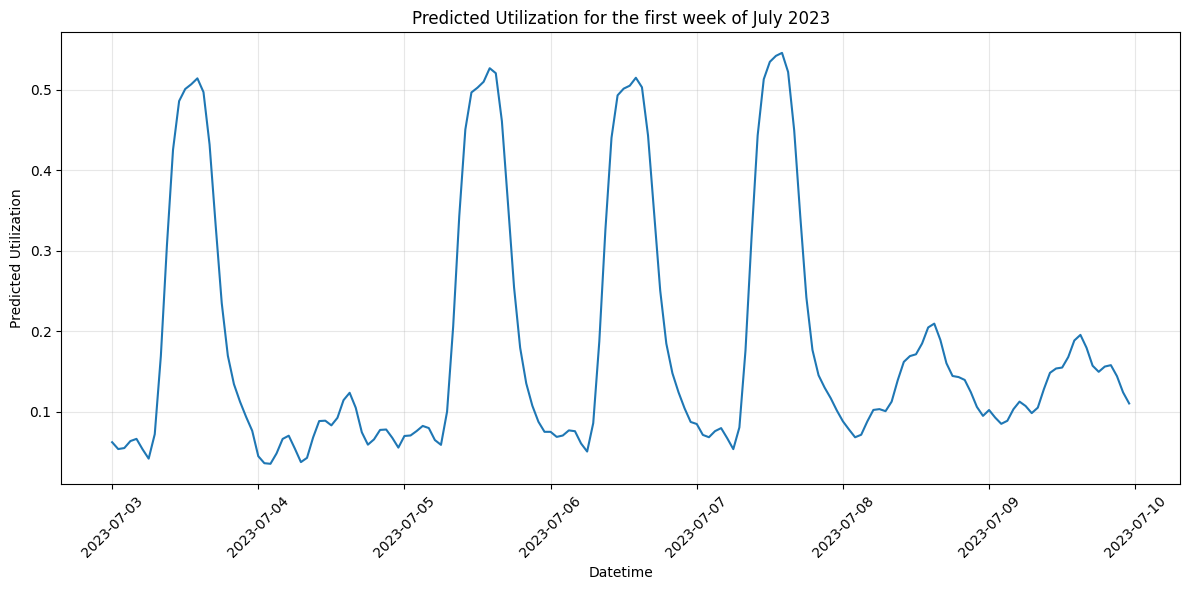

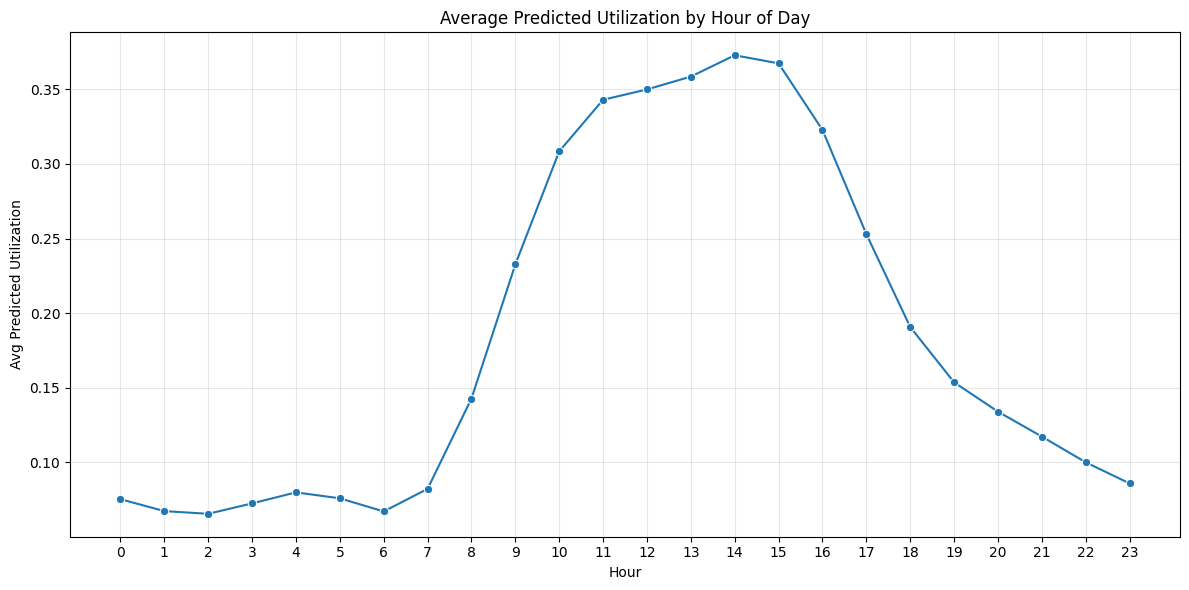

In [77]:
# ensure correct types and 1D array
df_future['datetime'] = pd.to_datetime(df_future['datetime'])

# Time series (first 7 days)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_future, x='datetime', y='predicted_utilization', marker=None)
plt.title('Predicted Utilization for the first week of July 2023')
plt.xlabel('Datetime')
plt.ylabel('Predicted Utilization')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Average predicted utilization by hour of day
df_future['hour'] = df_future['datetime'].dt.hour
hourly_mean = df_future.groupby('hour')['predicted_utilization'].mean().reindex(range(24))
plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_mean.index, y=hourly_mean.values, marker='o')
plt.title('Average Predicted Utilization by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Predicted Utilization')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The model makes reasonable predictions, with Average Predicet Utilization by Hour of Day looking similar to plots explored in the descriptives part. It is also able to correctly identify holidays and weekends as seen in the low utilization rate on July 4th, 8th and 9th. 

## Example for discounted price

Assuming that the optimal load for a given site is at 80%, we can give out discounts to registered users when the load is less than that. The discount given out is 1% for every 10% that we are off the optimal load, rounded downwards.
Example cases:

Predictet_utilization = 0,45 -> 3% Discount

Predictet_utilization = 0,35 -> 4% Discount

Predictet_utilization = 0,75 -> 0% Discount

In [74]:
# Calculate price discount
df_future['discount'] = df_future['discount'] = (np.floor(np.clip(0.8 - df_future['predicted_utilization']
                                              .clip(lower=0), 0, None) / 0.1) * 0.01)


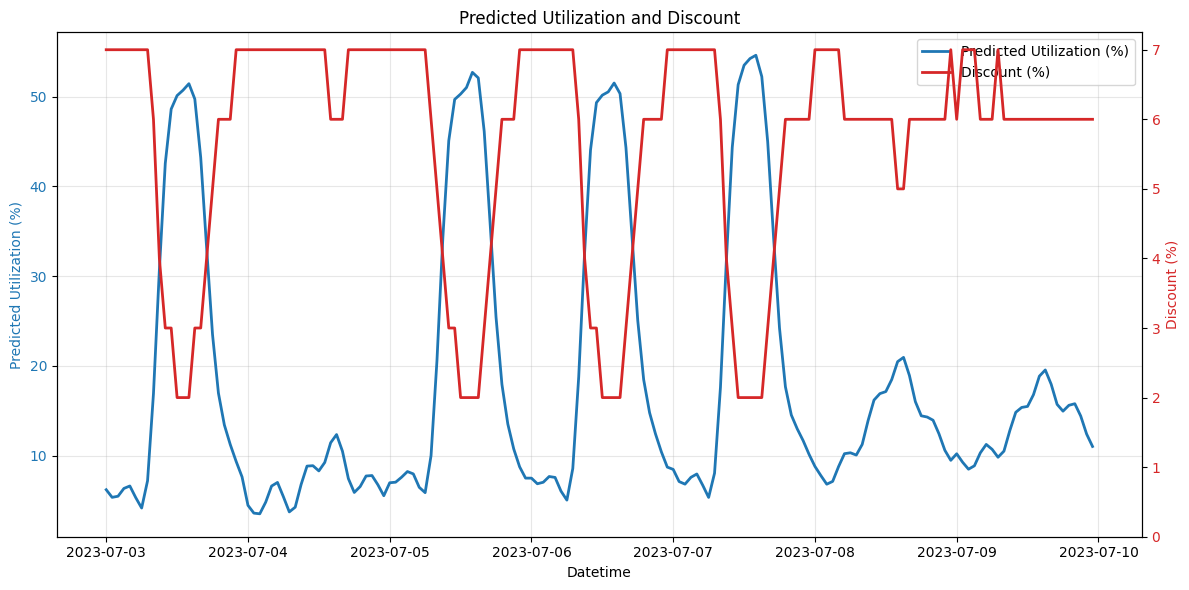

In [75]:
# Convert to percent
util_pct = df_future['predicted_utilization'] * 100
discount_pct = df_future['discount'] * 100
times = pd.to_datetime(df_future['datetime'])

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

ln1 = ax1.plot(times, util_pct, color='tab:blue', label='Predicted Utilization (%)', linewidth=2)
ax1.set_xlabel('Datetime')
ax1.set_ylabel('Predicted Utilization (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ln2 = ax2.plot(times, discount_pct, color='tab:red', label='Discount (%)', linewidth=2)
ax2.set_ylabel('Discount (%)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# combined legend and formatting
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
plt.ylim(bottom=0)
plt.title('Predicted Utilization and Discount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The plot shows the development of the discount price in relation to the predicted values for utilization. When utilization is predicted to be high, the discount rate drops, when utilization is predicted to be low, the discount rate rises. It therefore counteracts the utilization rate, implementing a form of dynamic pricing by lowering prices when demand is low and raising them, when demand is high.

These discount rates can be offered to registered users inside an app when booking a charging session e.g. a week in advance. As soon as a booking is made, the requested booking session will be added to the predicted utilization so that no "overbooking" can occur. This feature supports user engagement by rewarding registered users, flattens demand by offering discounts relative to predicted utilization rate and enhances overall energy throughput as lower prices attract new users.